# PRUEBAS DE INDEPENDENCIA ESTADÍSTICA
## Fundamentos y aplicación en Python

## 1. Definición de independencia

Dos variables aleatorias se consideran independientes cuando el conocimiento del valor de una de ellas no proporciona información acerca del valor de la otra.

**Definición formal:**

Sean $X$ e $Y$ dos variables aleatorias. Se dice que $X$ e $Y$ son independientes si para todo $x$, $y$ se cumple:

$$P(X = x \cap Y = y) = P(X = x) \cdot P(Y = y)$$

El símbolo $\cap$ denota la intersección de eventos, es decir, la ocurrencia simultánea.

**Ejemplo numérico con dados:**

Sea $A$ el evento "obtener un 6 en un dado", $P(A) = \frac{1}{6}$. Sea $B$ el evento "obtener águila en una moneda", $P(B) = \frac{1}{2}$. Bajo independencia:

$$P(A \cap B) = \frac{1}{6} \times \frac{1}{2} = \frac{1}{12} \approx 0.083$$

**Hipótesis estadísticas:**

- Hipótesis nula ($H_0$): Las variables son independientes
- Hipótesis alternativa ($H_1$): Las variables no son independientes (existe asociación)

**Regla de decisión:**

Sea $\alpha = 0.05$ el nivel de significancia. Si $p < \alpha$, se rechaza $H_0$. Si $p \geq \alpha$, no se rechaza $H_0$.

## 2. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact

print("Librerías cargadas")

Librerías cargadas


## 3. Correlación de Pearson

El coeficiente de correlación de Pearson, denotado como $r$, mide la relación lineal entre dos variables cuantitativas.

**Fórmula:**

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Interpretación de $r$:**

- $r = 1$: correlación lineal perfecta positiva
- $r = -1$: correlación lineal perfecta negativa
- $r = 0$: ausencia de correlación lineal

**Criterios de magnitud ($|r|$):**

| Rango | Interpretación |
|-------|----------------|
| 0.00 - 0.19 | Muy débil |
| 0.20 - 0.39 | Débil |
| 0.40 - 0.59 | Moderada |
| 0.60 - 0.79 | Fuerte |
| 0.80 - 1.00 | Muy fuerte |

**Ejemplo: horas de estudio, calificación**

=== CORRELACIÓN DE PEARSON ===
r = 0.9922
p = 0.0000
Decisión: Se rechaza H₀
Conclusión: Existe relación lineal.


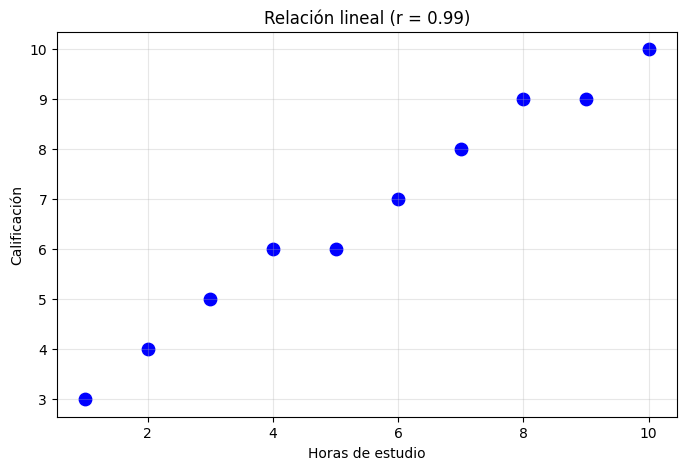

In [3]:
horas_estudio = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
calificacion = [3, 4, 5, 6, 6, 7, 8, 9, 9, 10]

r, p_valor = pearsonr(horas_estudio, calificacion)

print("=== CORRELACIÓN DE PEARSON ===")
print(f"r = {r:.4f}")
print(f"p = {p_valor:.4f}")

if p_valor < 0.05:
    print("Decisión: Se rechaza H₀")
    print("Conclusión: Existe relación lineal.")
else:
    print("Decisión: No se rechaza H₀")
    print("Conclusión: No hay evidencia de relación lineal.")

plt.figure(figsize=(8,5))
plt.scatter(horas_estudio, calificacion, color='blue', s=80)
plt.xlabel('Horas de estudio')
plt.ylabel('Calificación')
plt.title(f'Relación lineal (r = {r:.2f})')
plt.grid(True, alpha=0.3)
plt.show()

**Ejemplo: estatura, número de letras del nombre (independencia)**

r = 0.3995, p = 0.4327
Decisión: No se rechaza H₀ (independencia)


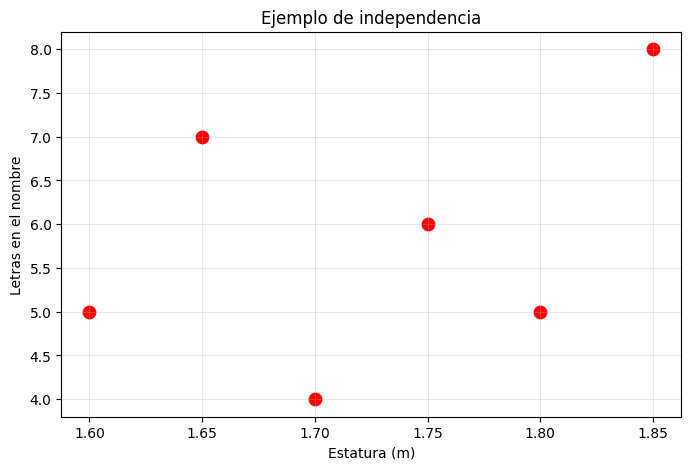

In [4]:
estatura = [1.60, 1.65, 1.70, 1.75, 1.80, 1.85]
letras_nombre = [5, 7, 4, 6, 5, 8]

r, p_valor = pearsonr(estatura, letras_nombre)

print(f"r = {r:.4f}, p = {p_valor:.4f}")

if p_valor < 0.05:
    print("Decisión: Se rechaza H₀")
else:
    print("Decisión: No se rechaza H₀ (independencia)")

plt.figure(figsize=(8,5))
plt.scatter(estatura, letras_nombre, color='red', s=80)
plt.xlabel('Estatura (m)')
plt.ylabel('Letras en el nombre')
plt.title('Ejemplo de independencia')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Correlación de Spearman

El coeficiente de Spearman, denotado como $\rho$ (rho), mide la relación monótona entre dos variables. Una relación monótona implica que cuando una variable aumenta, la otra también aumenta (o disminuye), sin requerir linealidad.

**Fórmula:**

$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$

donde $d_i$ es la diferencia entre los rangos.

**Ejemplo: relación exponencial**

=== COMPARACIÓN ===
Pearson: r = 0.7988, p = 0.0056
Spearman: ρ = 1.0000, p = 0.0000
Spearman detecta relación monótona.


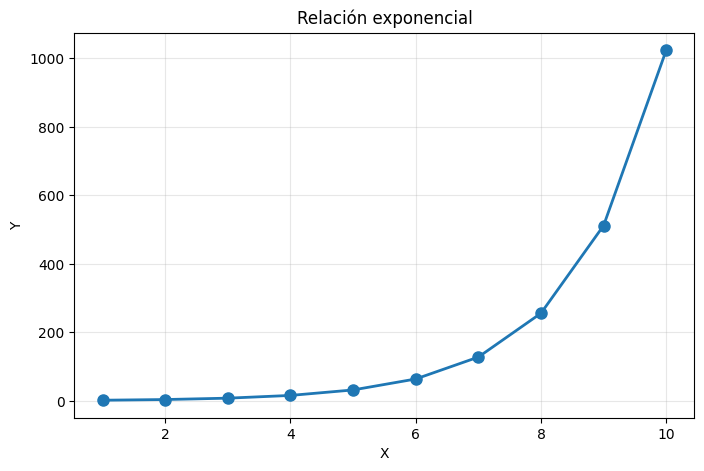

In [5]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

r_pearson, p_pearson = pearsonr(x, y)
rho_spearman, p_spearman = spearmanr(x, y)

print("=== COMPARACIÓN ===")
print(f"Pearson: r = {r_pearson:.4f}, p = {p_pearson:.4f}")
print(f"Spearman: ρ = {rho_spearman:.4f}, p = {p_spearman:.4f}")

if p_spearman < 0.05:
    print("Spearman detecta relación monótona.")

plt.figure(figsize=(8,5))
plt.plot(x, y, 'o-', markersize=8, linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Relación exponencial')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Prueba Chi-Cuadrado de independencia

La prueba Chi-cuadrado ($\chi^2$) se utiliza para evaluar si **dos variables categóricas están asociadas** o si son independientes.

---

### Idea fundamental

Se comparan:
- **Frecuencias observadas** ($O_{ij}$): datos reales
- **Frecuencias esperadas** ($E_{ij}$): lo que esperaríamos si las variables fueran independientes

Si hay mucha diferencia entre ambas, existe evidencia de dependencia.

---

### Frecuencias esperadas

Bajo la hipótesis de independencia, cada celda $(i,j)$ se calcula como:

$$
E_{ij} = \frac{R_i \cdot C_j}{N}
$$

donde:
- $R_i$: total de la fila $i$
- $C_j$: total de la columna $j$
- $N$: total de observaciones

---

### Estadístico de prueba

$$
\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

Este estadístico mide qué tan lejos están los datos observados de lo esperado.

---

### Grados de libertad

$$
gl = (r - 1)(c - 1)
$$

donde:
- $r$: número de filas
- $c$: número de columnas

---

### Interpretación

- Valores grandes de $\chi^2$ → mayor evidencia contra la independencia
- Se usa el **p-valor** o un **valor crítico** para tomar la decisión

---

### Ejemplo: Género vs Preferencia de producto

Se desea evaluar si la preferencia de compra depende del género.

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Crear tabla de contingencia (datos observados)
tabla = np.array([[30, 20],   # Hombres: Sí, No
                  [20, 30]])  # Mujeres: Sí, No

# Convertir a DataFrame para visualización
df_tabla = pd.DataFrame(tabla, 
                        index=["Hombre", "Mujer"], 
                        columns=["Compra_Si", "Compra_No"])

print("Tabla de contingencia:")
print(df_tabla)

# Aplicar prueba Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla)

print("\nResultados:")
print("Chi-cuadrado:", chi2)
print("p-valor:", p)
print("Grados de libertad:", dof)

print("\nFrecuencias esperadas:")
print(expected)

Tabla de contingencia:
        Compra_Si  Compra_No
Hombre         30         20
Mujer          20         30

Resultados:
Chi-cuadrado: 3.24
p-valor: 0.07186063822585143
Grados de libertad: 1

Frecuencias esperadas:
[[25. 25.]
 [25. 25.]]


## 6. Prueba exacta de Fisher

La prueba exacta de Fisher se utiliza para evaluar la **independencia entre dos variables categóricas en tablas 2×2**, especialmente cuando:

- El tamaño de muestra es pequeño (por ejemplo, $n < 40$)
- Existen frecuencias esperadas menores a 5

A diferencia de Chi-cuadrado, **no usa aproximaciones**, sino que calcula probabilidades exactas.

---

### Hipótesis

- $H_0$: Las variables son independientes  
- $H_1$: Existe asociación entre las variables  

---

### Estructura de la tabla 2×2

$$
\begin{matrix}
a & b \\
c & d
\end{matrix}
\quad \text{con } N = a + b + c + d
$$

---

### Probabilidad exacta

La probabilidad de observar esta tabla (o una más extrema) bajo $H_0$ es:

$$
P = \frac{(a+b)!(c+d)!(a+c)!(b+d)!}{a!\,b!\,c!\,d!\,N!}
$$

---

### Interpretación del p-valor

- **p pequeño (por ejemplo, $p < 0.05$)**  
  → La tabla observada es poco probable bajo independencia  
  → **Se rechaza $H_0$**  
  → Hay evidencia de **dependencia**

- **p grande (por ejemplo, $p \ge 0.05$)**  
  → La tabla es compatible con independencia  
  → **No se rechaza $H_0$**  
  → No hay evidencia suficiente de asociación  


### Ejemplo: estudio clínico con 20 pacientes

Se analiza si un tratamiento influye en la recuperación:

|              | Recupera | No recupera |
|--------------|----------|-------------|
| Tratamiento  |    a     |      b      |
| Control      |    c     |      d      |

La prueba evalúa si las diferencias observadas entre tratamiento y control son atribuibles al azar o no.

In [9]:
import numpy as np
from scipy.stats import fisher_exact

# Ejemplo: estudio clínico
#              Recupera   No recupera
# Tratamiento      8            2
# Control          3            7

tabla = np.array([[8, 2],
                  [3, 7]])

# Aplicar prueba de Fisher
oddsratio, p_value = fisher_exact(tabla)

print("Tabla:")
print(tabla)

print("\nResultados:")
print("p-valor:", p_value)

# Interpretación simple
alpha = 0.05

if p_value < alpha:
    print("\nConclusión: Se rechaza H0 → hay evidencia de dependencia")
else:
    print("\nConclusión: No se rechaza H0 → no hay evidencia de dependencia")

Tabla:
[[8 2]
 [3 7]]

Resultados:
p-valor: 0.06977851869492736

Conclusión: No se rechaza H0 → no hay evidencia de dependencia


## 7. Tau de Kendall

El coeficiente Tau de Kendall ($\tau$ mide la **fuerza y dirección de la asociación** entre dos variables ordinales o cuantitativas, basándose en la comparación de pares de observaciones.

---

### Idea fundamental

Se analizan todos los pares posibles de datos $(x_i, y_i)$ y $(x_j, y_j)$ con $i < j$:

- **Par concordante**:  
  Si el orden entre $x$ y $y$ coincide  
  (ambos aumentan o ambos disminuyen)

- **Par discordante**:  
  Si el orden es opuesto  
  (uno aumenta mientras el otro disminuye)

---

### Definición

Sea:
- $C$: número de pares concordantes  
- $D$: número de pares discordantes  

Entonces:

$$
\tau = \frac{C - D}{\frac{n(n-1)}{2}}
$$

donde:
- $\frac{n(n-1)}{2}$ es el número total de pares posibles

---

### Interpretación

- $\tau = 1$ → asociación positiva perfecta  
- $\tau = -1$ → asociación negativa perfecta  
- $\tau = 0$ → no hay asociación monotónica  



In [10]:
import numpy as np
from scipy.stats import kendalltau

# Datos de ejemplo
# x y y tienen una relación parcialmente monotónica
x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 3, 2, 5, 4])

# Cálculo de Tau de Kendall
tau, p_value = kendalltau(x, y)

print("Tau de Kendall:", tau)
print("p-valor:", p_value)

# Interpretación
alpha = 0.05

if p_value < alpha:
    print("\nConclusión: Hay evidencia de asociación (se rechaza H0)")
else:
    print("\nConclusión: No hay evidencia de asociación")

Tau de Kendall: 0.6
p-valor: 0.23333333333333334

Conclusión: No hay evidencia de asociación


## 8. Guía de selección de pruebas

| Tipo de variable X | Tipo de variable Y | Prueba |
|--------------------|--------------------|--------|
| Cuantitativa | Cuantitativa (lineal) | Pearson |
| Cuantitativa | Cuantitativa (monótona) | Spearman |
| Cuantitativa | Cuantitativa (ordinal) | Kendall |
| Categórica | Categórica (n > 40) | Chi-cuadrado |
| Categórica | Categórica (n < 40, tabla 2×2) | Fisher |

**Regla unificada:** Si $p < 0.05$, se rechaza la independencia.

## 9. Ejercicio con dataset tips

Dataset tips
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
Registros: 244

--- Análisis 1: total_bill, tip ---
Pearson: r = 0.676, p = 0.000000
Conclusión: Existe relación lineal.

--- Análisis 2: sex, smoker ---
Chi-cuadrado: p = 1.0000
Conclusión: No existe asociación (independencia).

--- Análisis 3: day, time ---
Chi-cuadrado: p = 0.000000
Conclusión: Existe asociación.


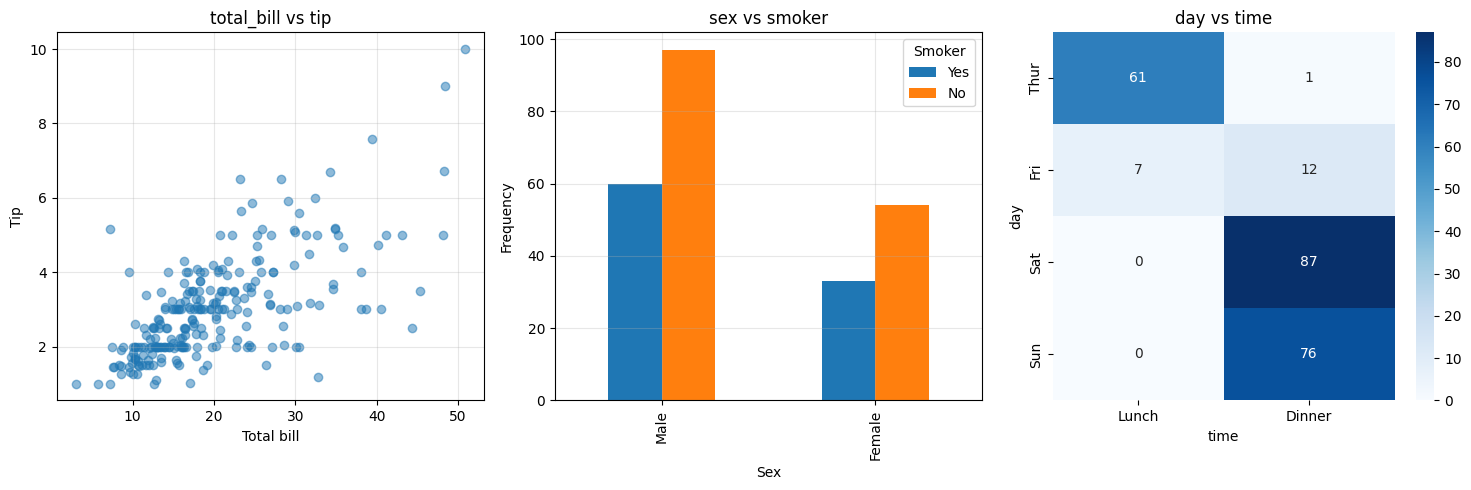

In [11]:
tips = sns.load_dataset("tips")

print("Dataset tips")
print(tips.head())
print(f"Registros: {len(tips)}")

print("\n--- Análisis 1: total_bill, tip ---")
r, p = pearsonr(tips['total_bill'], tips['tip'])
print(f"Pearson: r = {r:.3f}, p = {p:.6f}")

if p < 0.05:
    print("Conclusión: Existe relación lineal.")

print("\n--- Análisis 2: sex, smoker ---")
tabla_sex_smoker = pd.crosstab(tips['sex'], tips['smoker'])
chi2, p, dof, esp = chi2_contingency(tabla_sex_smoker)
print(f"Chi-cuadrado: p = {p:.4f}")

if p < 0.05:
    print("Conclusión: Existe asociación.")
else:
    print("Conclusión: No existe asociación (independencia).")

print("\n--- Análisis 3: day, time ---")
tabla_day_time = pd.crosstab(tips['day'], tips['time'])
chi2, p, dof, esp = chi2_contingency(tabla_day_time)
print(f"Chi-cuadrado: p = {p:.6f}")

if p < 0.05:
    print("Conclusión: Existe asociación.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(tips['total_bill'], tips['tip'], alpha=0.5)
axes[0].set_xlabel('Total bill')
axes[0].set_ylabel('Tip')
axes[0].set_title('total_bill vs tip')
axes[0].grid(True, alpha=0.3)

tabla_sex_smoker.plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Frequency')
axes[1].set_title('sex vs smoker')
axes[1].legend(title='Smoker')
axes[1].grid(True, alpha=0.3)

sns.heatmap(tabla_day_time, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('day vs time')

plt.tight_layout()
plt.show()

## 10. Resumen

**Definiciones fundamentales:**

- Independencia: $P(A \cap B) = P(A)P(B)$
- $H_0$: independencia
- $H_1$: dependencia (asociación)
- Regla: $p < 0.05 \Rightarrow$ rechazar $H_0$

**Pruebas según tipo de variable:**

| Situación | Prueba |
|-----------|--------|
| Relación lineal | Pearson |
| Relación monótona | Spearman |
| Categóricas (n grande) | Chi-cuadrado |
| Categóricas (n pequeño, 2×2) | Fisher |

# Importancia de `scipy.stats` en Análisis Estadístico y Ciencia de Datos

La librería `scipy.stats` constituye la columna vertebral del análisis estadístico en Python, proporcionando implementaciones sencillas y eficientes de los métodos estadísticos más utilizados en la práctica profesional.

---

## Áreas clave donde `scipy.stats` sobresale

### 1. Pruebas de Hipótesis
Contiene implementaciones de las pruebas más comunes

### 2. Pruebas de Independencia
- **Chi-cuadrado** (`chi2_contingency`): asociación entre variables categóricas
- **Fisher exacta** (`fisher_exact`): tablas 2×2 con muestras pequeñas
- **Correlaciones** (`pearsonr`, `spearmanr`, `kendalltau`): dependencia entre variables continuas

### 3. Bondad de Ajuste
- **Shapiro-Wilk** (`shapiro`): prueba de normalidad
- **Kolmogorov-Smirnov** (`kstest`): comparación contra distribución teórica
- **Anderson-Darling** (`anderson`): normalidad con más potencia
- **Chi-cuadrado de bondad** (`chisquare`): frecuencias esperadas vs observadas

### 4. Análisis Exploratorio de Datos (EDA)
- **Estadísticos descriptivos** (`describe`, `skew`, `kurtosis`)
- **Funciones de densidad y probabilidad** (`pdf`, `cdf`, `ppf`)
- **Generación de datos** (`norm.rvs`, `uniform.rvs`, etc.)

---

## Ventajas prácticas

| Característica | Beneficio |
|----------------|------------|
| **Implementación vectorizada** | Mayor velocidad que implementaciones caseras |
| **Manejo correcto de casos borde** | Evita errores comunes (división por cero, NaN) |
| **Documentación exhaustiva** | Fórmulas, referencias y ejemplos incluidos |
| **Algoritmos numéricamente estables** | Resultados precisos incluso con datos extremos |
| **Integración con NumPy/Pandas** | Trabaja directamente con arrays y DataFrames |


## Referencias

- Agresti, A. (2018). *Statistical Methods for the Social Sciences* (5th ed.). Pearson.  
  → Referencia clásica para tablas de contingencia, prueba chi-cuadrado y medidas de asociación como V de Cramér.

- Casella, G., & Berger, R. L. (2002). *Statistical Inference* (2nd ed.). Duxbury.  
  → Texto teórico fundamental que cubre pruebas de hipótesis, incluyendo independencia y pruebas exactas como Fisher.

- Wasserman, L. (2004). *All of Statistics: A Concise Course in Statistical Inference*. Springer.  
  → Introducción moderna y rigurosa a inferencia estadística, incluyendo pruebas de independencia y correlación.